In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import sys

In [2]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

 cupy not imported 
2.5.1


In [3]:
import mlx.core as mx
import mlx
print(mx.metal.is_available())

True


In [4]:
torch.backends.mps.is_available()

True

In [5]:
transform = transforms.Compose(
    [transforms.Grayscale(num_output_channels=1),transforms.Resize([8,8]),transforms.ToTensor()])

In [6]:
print(8*8)
print(16*16)
print(32*32)

64
256
1024


In [7]:
batch_size = 32
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
print(trainset.classes)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

Files already downloaded and verified
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Files already downloaded and verified


In [8]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

In [9]:
def test_imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

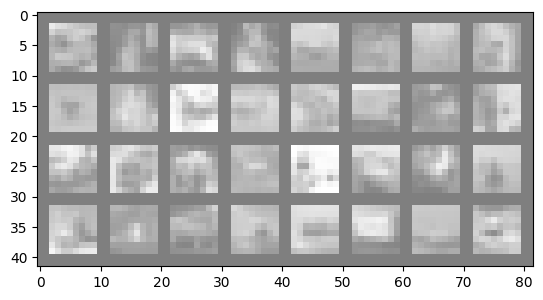

In [10]:
test_imshow(torchvision.utils.make_grid(images))

torch.Size([32, 1, 8, 8])
(8, 8, 1)
tensor(3)


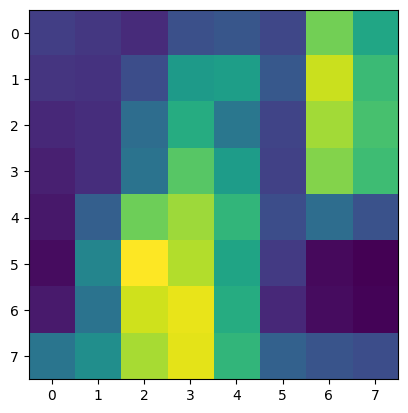

In [11]:
print(images.shape)
print(np.transpose(images[1].numpy(),(1,2,0)).shape)
print(labels[1])
plt.imshow(np.transpose(images[1].numpy(),(1,2,0)))

6
frog


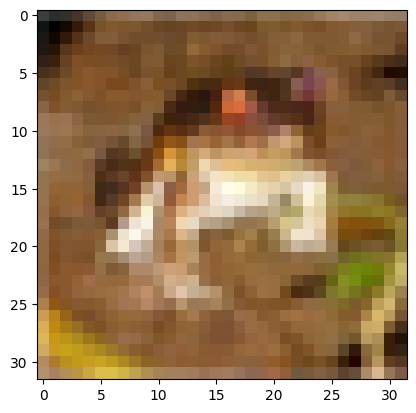

In [12]:
plt.imshow(trainset.data[0].reshape(32,32,3))
print(trainset.targets[0])
print(trainset.classes[trainset.targets[0]])

In [13]:
pca  = PCA(128)
gimage = transforms.Grayscale()(torch.Tensor(np.transpose(trainset.data,(0,3,1,2)))).reshape(-1,32*32*1)
pctrain = pca.fit_transform(gimage)

343.81750832356454
-67.53437045479558


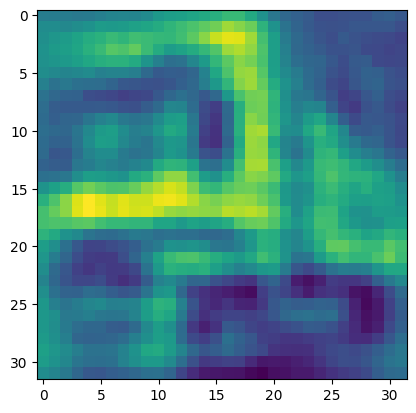

In [14]:
reconstructed_train = pca.inverse_transform(pctrain)
print(np.max(reconstructed_train))
print(np.min(reconstructed_train))
scaler = MinMaxScaler()
reconstructed_train = scaler.fit_transform(reconstructed_train)
plt.imshow(reconstructed_train[1].reshape(32,32,1))


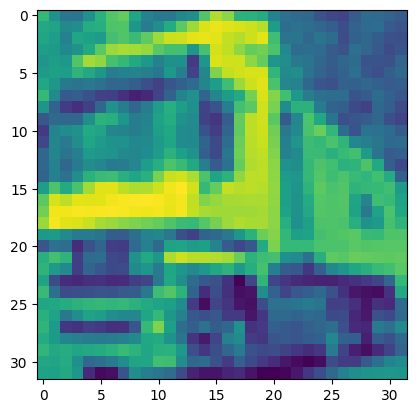

In [15]:
plt.imshow(gimage[1].reshape(32,32,1))


In [16]:
print(pctrain)
print(pctrain.shape)

[[-7.06456546e+02  4.54084529e+02 -3.97826090e+02 ... -7.78434596e+01
   5.72539856e+01  6.46044758e+01]
 [ 4.41807779e+01 -1.62381591e+02 -8.79721774e+02 ... -8.75806685e+01
   2.14965733e+01  2.56405390e+01]
 [ 1.08404866e+03 -1.74883261e+03  3.44717063e+02 ...  8.99384477e+00
  -2.00993813e+01  1.02901054e+01]
 ...
 [-9.12367095e+01 -1.64853983e+03  1.59828934e+02 ...  1.09676297e+01
  -1.44032265e+01 -1.29813699e+01]
 [ 1.51786036e+03 -4.77072534e+02 -7.96496392e+02 ... -1.19088823e-01
   1.86168925e+00  4.37076954e+01]
 [ 5.71133094e+02 -1.97472066e+02  6.44725144e+02 ... -1.92283837e+01
  -5.06000185e+01  3.15367096e+01]]
(50000, 128)


(50000, 32, 32, 3)
6
frog


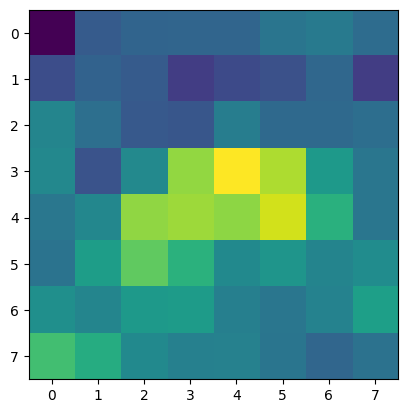

In [17]:
print(trainset.data.shape)
train_set_array = transforms.Grayscale()(torch.Tensor(np.transpose(trainset.data,(0,3,1,2))))
train_set_array = transforms.Resize([8,8])(train_set_array)
plt.imshow(train_set_array[0].numpy().reshape(8,8))
print(trainset.targets[0])
print(trainset.classes[trainset.targets[0]])


In [18]:
train_set_array = pctrain
print(train_set_array.shape)
#reshaped_trainset = mx.array(trainset.data.reshape(-1,32*32*3),dtype=mx.float16)
#reshaped_trainset = mx.array(train_set_array.numpy().reshape(-1,8*8*1),dtype=mx.float16)
scalerF = MinMaxScaler((-1,1))
reshaped_trainset = mx.array(scalerF.fit_transform(train_set_array).reshape(-1,128),dtype=mx.float16)
print(reshaped_trainset.shape)
print(reshaped_trainset)

(50000, 128)
(50000, 128)
array([[-0.226685, 0.086853, -0.197754, ..., -0.385498, 0.154785, 0.281738],
       [-0.0183411, -0.127686, -0.417236, ..., -0.425049, 0.0189056, 0.101624],
       [0.270264, -0.679688, 0.140747, ..., -0.0326843, -0.13916, 0.0306854],
       ...,
       [-0.0559387, -0.64502, 0.056488, ..., -0.0246735, -0.117493, -0.0768433],
       [0.390869, -0.237183, -0.379395, ..., -0.0697021, -0.0556946, 0.185059],
       [0.12793, -0.139893, 0.277588, ..., -0.147339, -0.255127, 0.128906]], dtype=float16)


In [19]:
BSIZE = 8
GSIZE = 128
qtrain, strain, btrain = mx.quantize(reshaped_trainset[:,:],group_size=GSIZE,bits=BSIZE)
print(qtrain.shape)
print(qtrain.dtype)
print(strain.shape)
print(strain.dtype)
print(btrain.shape)
print(btrain.dtype)
print(btrain[:4,:])
print(128/128)
print(128/32*8)

(50000, 32)
mlx.core.uint32
(50000, 1)
mlx.core.float16
(50000, 1)
mlx.core.float16
array([[0.46167],
       [0.677734],
       [-0.679688],
       [-0.422119]], dtype=float16)
1.0
32.0


I think I have an equation
I have 2, 4, 8 bits

In [20]:
def qmlx_nu_dft(qx: mx.array, qs: mx.array, qb: mx.array, y: mx.array, f: mx.array, bsize: int = 2, gsize:int = 128, GZ: int = 1024) -> (mx.array, mx.array): 
    '''
    Directly computes in the DFT for non-uniformly sampled inputs and non-uniformly sampled frequency vectors
    The computation complexity is of order NxdxM, and is intended for sparse collections of input and output samples in large d cases.                                                                                                                                            
    Args:
    x: Nxd array of arbitrary input vectors, each row being a vector of dimension d                                                                                                                                                                                  
    y: Nx1 array of function values at x
    f: A Mxd array of arbitrary frequency vectors
    Returns:
    Mx1 array representing the DFT of the function
    '''

    if (len(y.shape)==1): # common mistake                                                                                                                                                                  
        y = y.reshape(y.shape[0],1)

    #w = mx.transpose(-2.0*np.pi*f)

    N = qx.shape[0]
    M = f.shape[0]//GZ
    yfr = mx.zeros((f.shape[0],1),dtype=mx.float32)
    yfi = mx.zeros((f.shape[0],1),dtype=mx.float32)
    #print(yfr.shape,M,f.shape,qx.shape)

    for i in range(M):
        #print(qx.shape)
        tmp1 = -2.0*np.pi*mx.quantized_matmul(f[i*GZ:(i+1)*GZ,:],qx,scales=qs,biases=qb,transpose=True,group_size=gsize,bits=bsize)
        #print('second ')
        #print(wq,wq.shape)
        #print(s,s.shape)
        #print(b,b.shape)
        #print('quantized mx ',tmp1,tmp1.shape) 
        #print((mx.transpose(y)*mx.cos(tmp1,stream=mx.gpu)).shape)
        yfr[i*GZ:(i+1)*GZ,0] = mx.sum(mx.transpose(y)*mx.cos(tmp1,stream=mx.gpu),axis=1,stream=mx.gpu)
        yfi[i*GZ:(i+1)*GZ,0] = mx.sum(mx.transpose(y)*mx.sin(tmp1,stream=mx.gpu),axis=1,stream=mx.gpu)
    i = M
    ii = f.shape[0]
    if ii>i*GZ:
        tmp1 = -2.0*np.pi*mx.quantized_matmul(f[i*GZ:,:],qx,scales=qs,biases=qb,transpose=True,group_size=gsize,bits=bsize)
        #print('final ')
        #print(wq,wq.shape)
        #print(s,s.shape)
        #print(b,b.shape)        
        #print(tmp1,tmp1.shape)
        yfr[i*GZ:,0] = mx.sum(mx.transpose(y)*mx.cos(tmp1,stream=mx.gpu),axis=1,stream=mx.gpu)
        yfi[i*GZ:,0] = mx.sum(mx.transpose(y)*mx.sin(tmp1,stream=mx.gpu),axis=1,stream=mx.gpu)    

    return yfr,yfi

In [21]:
features = reshaped_trainset.shape[1]
#f = (mx.random.uniform(low=0,high=1,shape=[1024*features*4],dtype=mx.float16).reshape(-1,features)*2-1) * 12
#print(f)
f = mx.random.randint(low=-4,high=4,shape=[1024*40,features],dtype=mx.int8)
print(f)

array([[0, -3, -2, ..., 0, -1, 2],
       [-3, 3, 0, ..., 3, 1, 3],
       [0, -1, -3, ..., -2, 3, -2],
       ...,
       [-3, 2, -1, ..., 1, 0, 3],
       [-1, 3, -2, ..., -2, 2, -2],
       [2, -1, -3, ..., -3, -1, -1]], dtype=int8)


since I know each feature is just 256, I should not use uniform but instead integer, maybe I even wants to keep it to smaller numbers... and not 255?

In [22]:
print(f.shape)
print(reshaped_trainset.shape)

(40960, 128)
(50000, 128)


In [23]:
y = np.array(trainset.targets)
y[y!=4]=-1
y[y>0]=1
print(y.shape)
print(y[:5])
print(reshaped_trainset[:5,:10])
print(f.astype(mx.float16))

(50000,)
[-1 -1 -1  1 -1]
array([[-0.226685, 0.086853, -0.197754, ..., -0.297607, -0.0219574, -0.0635376],
       [-0.0183411, -0.127686, -0.417236, ..., -0.235962, 0.105408, -0.411621],
       [0.270264, -0.679688, 0.140747, ..., 0.0527039, -0.248779, 0.233521],
       [-0.422119, -0.0613708, -0.130493, ..., -0.132935, -0.189087, -0.0497742],
       [-0.195557, -0.303467, -0.0281677, ..., -0.355713, -0.343506, -0.303223]], dtype=float16)
array([[0, -3, -2, ..., 0, -1, 2],
       [-3, 3, 0, ..., 3, 1, 3],
       [0, -1, -3, ..., -2, 3, -2],
       ...,
       [-3, 2, -1, ..., 1, 0, 3],
       [-1, 3, -2, ..., -2, 2, -2],
       [2, -1, -3, ..., -3, -1, -1]], dtype=float16)


In [24]:
start = time.time()
yfr, yfi = qmlx_nu_dft(qtrain, strain, btrain ,mx.array(y,dtype=mx.float16),f.astype(mx.float16),BSIZE,GSIZE)
print(time.time()-start)

0.0017397403717041016


In [25]:
start = time.time()
yf = yfr.astype(mx.complex64)+1j*yfi.astype(mx.complex64)
print(time.time()-start)
print(yf)
print(yf.shape)
print(np.isnan(np.array(yf)).astype(np.int8).sum())

8.106231689453125e-05
array([[114.188-38.4062j],
       [-251.5+51.9375j],
       [-303.5+31.875j],
       ...,
       [-308.5+43.875j],
       [-8.5625-111j],
       [-164.125-219.75j]], dtype=complex64)
(40960, 1)
0


(40960, 128)


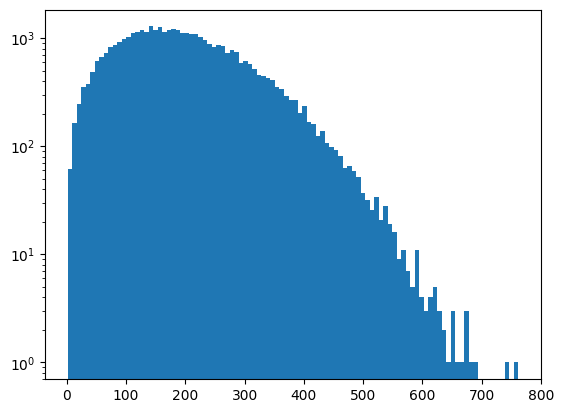

In [26]:
plt.hist(np.array(mx.abs(yf)),bins=100)
plt.yscale('log')
print(f.shape)

In [27]:
start = time.time()
ind =  np.argwhere(np.abs(np.array(yf)>700))
print(time.time()-start)
start = time.time()
ind =  np.argwhere(np.array(mx.abs(yf)>700))
print(time.time()-start)
print(ind.flags.owndata)


0.0031599998474121094
0.019359827041625977
False


In [28]:
new_f = np.array(np.array(f)[ind[:,0],:])
new_yf = np.array(yf)[ind[:,0]]
list_f = []
list_yf = []

In [29]:
def return_value(mask: mx.array,yf: mx.array,f: mx.array):
    #print(mask.shape,mx.sum(mask.astype(mx.uint8)))
    if mask.astype(mx.uint8).sum()>1:
        hsize = mask.shape[0]//2
        return_value(mask[:hsize,:],yf[:hsize,:],f[:hsize,:])
        return_value(mask[hsize:,:],yf[hsize:,:],f[hsize:,:])
        return
        #print(yf1,yf2)
        #if yf1==mx.array():
        #    return yf2,f2
        #if yf2==mx.array():
        #    return yf1,f2
        #else:
        #    return mx.stack([yf1,yf2]),mx.stack([f1,f2])
    if mask.astype(mx.uint8).sum()==1:
        #print(mask.shape,yf.shape,f.shape)
        #print(mask[:2,:])
        #print(f[:2,:])
        ryf = mx.where(mask,yf,0).sum()
        rf = mx.where(mask,f,0).sum(axis=0)
        #print(ryf)
        #print(rf.shape)
        list_f.append(rf)
        list_yf.append(ryf)
        return
    else:
        return

In [30]:
start = time.time()    
return_value(mx.abs(yf,stream=mx.gpu)>800,yf,f)
print(time.time()-start) 

0.03351902961730957


In [31]:
print(len(list_yf))
print(list_yf)
print(list_f)
list_f = [mx.array(np.array(f)[ind[:,0],:])]
list_yf = [mx.array(np.array(yf)[ind[:,0]])]

0
[]
[]


In [32]:
list_f = [new_f]
print(list_f)
list_yf = [new_yf]
print(new_yf.shape)

[array([[ 3,  2,  3,  2, -2,  1,  1,  0, -2,  3, -1, -1, -2, -1,  1,  0,
         1,  3,  1,  1,  0,  3, -1, -2, -1,  1,  3, -3,  3,  0,  3, -1,
        -2,  0, -3,  2, -1,  2,  3,  1,  1, -1, -3,  1,  1,  0, -3,  3,
        -1, -1,  0,  2, -1, -3,  0, -1,  0, -3,  1,  2, -3, -2, -1,  0,
         0, -3, -2,  1, -1,  1,  2,  3,  0, -3, -1,  2,  2,  1, -1, -1,
        -2,  1,  0,  3,  1,  0,  1, -2, -1,  2, -3, -3,  2,  1,  1,  1,
        -3, -2,  3, -2,  3, -2,  2, -2,  0,  0, -1, -3, -3,  2,  1,  3,
        -2,  3,  0,  0, -3,  1, -3,  2, -2,  2,  3,  3, -1, -3, -2,  0],
       [ 0, -1,  0,  0, -2,  1,  0, -2,  3,  1, -1, -1, -1,  3,  1, -3,
         2,  0, -1, -2,  1,  2,  1,  0,  0, -2,  0,  3, -1,  2, -3,  2,
         2, -3,  2, -1,  3,  0,  0, -3,  3,  0,  2, -3,  2,  1,  1,  2,
         2, -3,  2,  1,  3,  2,  3,  0, -1,  3,  3,  2,  1, -2,  2, -1,
         0,  0,  0,  3, -2,  0, -1,  2, -1,  0,  0, -3,  2, -3,  3, -3,
         0,  1,  2, -2,  0,  0,  2,  1,  1, -2,  2, -2,  2,  3

In [39]:
start2 = time.time()
for i in np.arange(100):
    f = mx.random.randint(low=-24,high=24,shape=[1024*40,features],dtype=mx.int8).astype(mx.float16)/4.
    yfr, you = qmlx_nu_dft(qtrain, strain, btrain ,mx.array(y,dtype=mx.float16),f,BSIZE,GSIZE)
    yf = yfr.astype(mx.complex64)+1j*yfi.astype(mx.complex64)
    #abs_yf = mx.abs(yf)
    yf = np.array(yf)
    f = np.array(f)
    #print(yf[0,:],f[0,:])
    #print(abs_yf)
    #ind_yf = mx.argsort(abs_yf)
    #print(ind_yf)
    #ind10 = ind_yf[-4:]
    #print(ind10)
    #list_f.append(f[ind10,:])
    #list_yf.append(yf[ind10,:])
    ind = np.abs(yf)>700
    list_f.append(f[ind[:,0],:])
    list_yf.append(yf[ind[:,0],:])
print(time.time()-start2)

2914.887438774109


In [40]:
print(len(list_yf))
#print(list_yf)
print(list_yf[3])
print(list_yf[4])
print(np.vstack([list_yf[3],list_yf[4]]))
new_yf = np.vstack(list_yf)
new_f = np.vstack(list_f)
print(new_f.shape)

211
[[115.125+726.j]]
[[318.+726.j]]
[[115.125+726.j]
 [318.   +726.j]]
(572, 128)


(572, 1)
(572, 128)


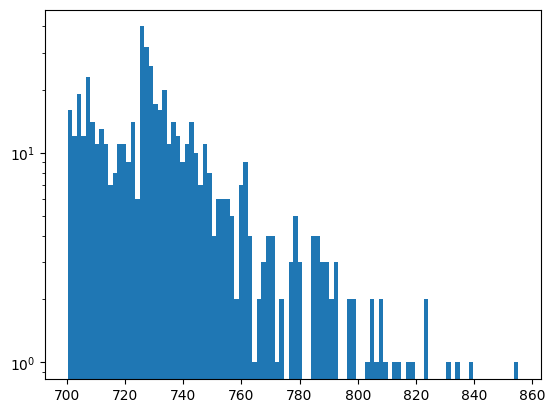

In [41]:
print(new_yf.shape)
print(new_f.shape)
plt.hist(np.abs(new_yf),bins=100)
plt.yscale('log')


In [ ]:
ind2 =  np.argwhere(np.abs(new_yf)>850)
print(ind2.shape)
f2 = np.array(new_f[ind2[:,0],:])
print(f2)